In [34]:
import pandas as pd

df = pd.read_csv(r"C:\Users\91916\Downloads\Telecom_Customer_Churn_Dataset.csv")

df

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...,...,...,...,...
2495,CUST02496,33,479.19,25890.63,Month-to-Month,No,Debit Card,No
2496,CUST02497,52,1241.50,85917.79,Two Year,No,Credit Card,No
2497,CUST02498,14,1172.06,54865.85,Month-to-Month,No,Credit Card,Yes
2498,CUST02499,53,778.37,57162.91,One Year,Fiber Optic,UPI,No


In [35]:
df.head()

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No


# Data Preprocessing

In [36]:
import numpy as np
a = df.select_dtypes(include= np.number)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
a = StandardScaler().fit_transform(a)

In [45]:
e = pd.DataFrame(a, columns=["Tenure_Motnhs","Monthly_Charges","Total_Charges"])

In [40]:
b = df.select_dtypes(include=["object"])
b

,CustomerID,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,Two Year,No,UPI,No
1,CUST00002,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,Month-to-Month,No,Credit Card,No
3,CUST00004,Two Year,DSL,Bank Transfer,No
4,CUST00005,One Year,Fiber Optic,Debit Card,No
...,...,...,...,...,...
2495,CUST02496,Month-to-Month,No,Debit Card,No
2496,CUST02497,Two Year,No,Credit Card,No
2497,CUST02498,Month-to-Month,No,Credit Card,Yes
2498,CUST02499,One Year,Fiber Optic,UPI,No


In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
for i in b:
    b[i] = LabelEncoder().fit_transform(b[i])

In [43]:
b

,CustomerID,Contract_Type,Internet_Service,Payment_Method,Churn
0,0,2,2,3,0
1,1,0,0,0,0
2,2,0,2,1,0
3,3,2,0,0,0
4,4,1,1,2,0
...,...,...,...,...,...
2495,2495,0,2,2,0
2496,2496,2,2,1,0
2497,2497,0,2,1,1
2498,2498,1,1,3,0


In [46]:
f = b.drop(columns=["CustomerID"], axis=1)

In [48]:
df = pd.concat([e,f],axis=1)


In [49]:
df.head()

,Tenure_Motnhs,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,0.824853,0.795057,0.891582,2,2,3,0
1,-0.982193,0.339162,0.822047,0,0,0,0
2,1.264404,-1.514061,1.320641,0,2,1,0
3,-0.689158,1.304896,0.787002,2,0,0,0
4,-0.542641,1.304957,-0.920776,1,1,2,0


# Feature Extraction

In [50]:
y = df["Churn"]
x = df.drop("Churn", axis=1)

# Train Test Split

In [51]:
from sklearn.model_selection import train_test_split

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Model Application

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
model = LogisticRegression()

In [56]:
model

LogisticRegression()

In [57]:
model.fit(x_train, y_train)

LogisticRegression()

# Prediction

In [58]:
y_pred = model.predict(x_test)

# Accuracy Score

In [61]:
from sklearn.metrics import accuracy_score

In [69]:
accuracy_score(y_test, y_pred)

0.73

In [ ]:
from sklearn.metrics import confusion_matrix

In [83]:
confusion_matrix(y_test, y_pred)

array([[365,   0],
       [135,   0]])

In [84]:
Accuracy = (360 + 0) / (360 + 140 + 0 + 0)

In [85]:
Accuracy

0.72

In [86]:
from sklearn.metrics import classification_report

In [87]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.84       365
           1       0.00      0.00      0.00       135

    accuracy                           0.73       500
   macro avg       0.36      0.50      0.42       500
weighted avg       0.53      0.73      0.62       500



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [101]:
model.coef_[0]

array([-0.01161941, -0.05665742, -0.1286994 , -0.00188298,  0.08095869,
       -0.12082147])

In [90]:
x.columns

Index(['Tenure_Motnhs', 'Monthly_Charges', 'Total_Charges', 'Contract_Type',
       'Internet_Service', 'Payment_Method'],
      dtype='object')

In [102]:
import matplotlib.pyplot as plt

<BarContainer object of 6 artists>

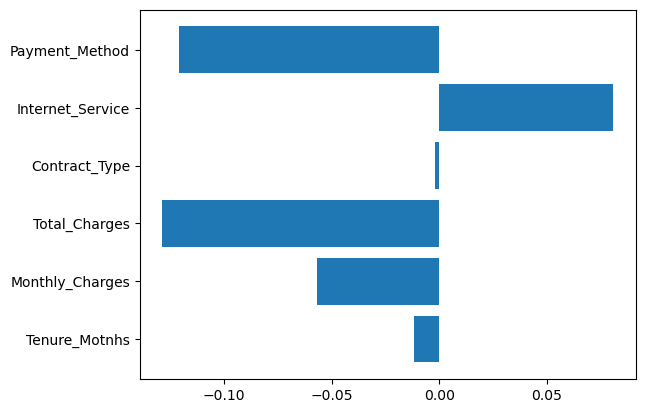

In [103]:
plt.barh(x.columns, model.coef_[0])

# Final Conclusion

### 1. Customers are churning because of low internet service